In [1]:
from ppg_basis import ppgGenerator
from ppg_basis import ppgExtractor
import matplotlib.pyplot as plt

In [ ]:
# Generate signal
ppgGen = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=4,
                      basis_type="gaussian")

sig = ppgGen.generate_signal()
plt.plot(sig)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original PPG")

[0.22976111 0.25809449 0.28612444 ... 0.23755789 0.24872282 0.25964743]


In [ ]:
# Extract signal parameters
ppgExt = ppgExtractor(signal=sig,
                      fs=125,
                      hr=60,
                      sigma=0,
                      L=4,
                      basis_type='gaussian')

theta_pred, params_pred = ppgExt.extract_ppg()

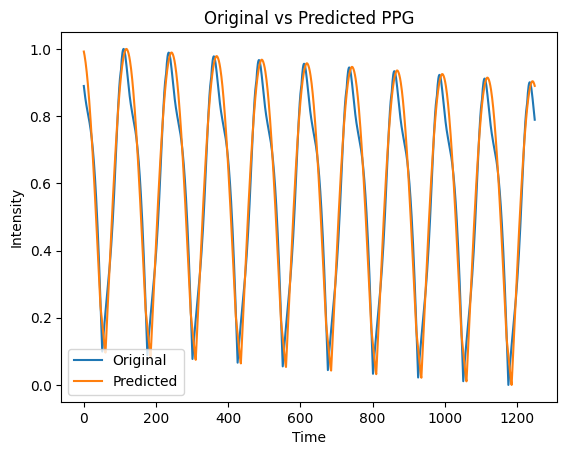

In [ ]:
# Generate PPG using extracted parameters
ppgPrd = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=4,
                      basis_type="gaussian",
                      thetas=theta_pred,
                      params=params_pred)
pred = ppgPrd.generate_signal()

plt.plot(sig)
plt.plot(pred)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original vs Predicted PPG")
plt.legend(["Original", "Predicted"])

In [5]:
# Fig. 4: Show utility in phase extraction and data augmentation
# Later part of paper could argue about augmentated trial datasets, and use for future ML
# Noise resistance models w/ DNNs